# Gaming Analytics Case Study: Player Funnel, Conversion, and Retention Analysis

Data Clearning & Pre-processing

In [1]:
#load the data
import pandas as pd
bonus = pd.read_excel('BonusCost_Data.xlsx')
firstbet = pd.read_excel('First_Bet_Data.xlsx')
firstdeposit = pd.read_excel('First_Deposit_Data.xlsx')
playeractivity = pd.read_excel('Player_Activity_Data.xlsx')
playerdetails = pd.read_excel('Player_Details.xlsx')

In [2]:
#rename columns for better readability
#bonus
bonus = bonus.rename(columns={
    "Src_PLAYER_ID": "player_id",
    "ActivityMonth": "activity_month",
    "Product": "bonus_product",
    "BONUS_COST": "bonus_cost"
})
bonus["activity_month"] = pd.to_datetime(bonus["activity_month"])
bonus.head()

,player_id,activity_month,bonus_product,bonus_cost
0,16051927,2020-06-30,eGaming,50.0
1,19309540,2021-02-28,eGaming,40.0
2,13176431,2020-01-31,eGaming,15.0
3,12405628,2019-02-28,SportsBook,30.0
4,17486248,2021-02-28,eGaming,25.0


In [3]:
bonus.isnull().sum() #check for missing values

player_id         0
activity_month    0
bonus_product     0
bonus_cost        0
dtype: int64

In [4]:
#firstbet
firstbet = firstbet.rename(columns={
    "Src_Player_Id": "player_id",
    "System_First_Bet_Datetime": "first_bet_datetime",
    "System_First_BetSlip_Amt": "first_betsilp_amount",
    "System_First_Bet_Product_Group": "first_bet_product_group",
    "System_First_Bet_Product": "first_bet_product",
    "System_First_Bet_Channel": "first_bet_channel",
    "System_First_Bet_Platform": "first_bet_platform"
})
firstbet["first_bet_datetime"] = pd.to_datetime(firstbet["first_bet_datetime"])
firstbet.head()

,player_id,first_bet_datetime,first_betsilp_amount,first_bet_product_group,first_bet_product,first_bet_channel,first_bet_platform
0,15643431,2020-10-09 03:57:29.000,2.5,eGaming,Non Table Games,Online,Mobile
1,13593034,2019-09-27 15:03:58.244,10.0,Sports,Prematch,Online,Mobile
2,15894194,2021-02-28 02:22:07.000,2.0,eGaming,Non Table Games,Online,Web
3,13238000,2019-07-08 10:39:45.000,0.4,eGaming,Non Table Games,Online,Mobile
4,12866848,2019-04-27 14:20:27.000,0.4,eGaming,Non Table Games,Online,Mobile


In [5]:
firstbet.isnull().sum() #check for missing values

player_id                       0
first_bet_datetime         133619
first_betsilp_amount       133619
first_bet_product_group    133619
first_bet_product          133619
first_bet_channel          133619
first_bet_platform         133619
dtype: int64

There are many nulls present in the data set this is Because
1) Some player registered but never deposited
2) Some player deposited but never place bet
3) those who deposited and bat are active

In [6]:
#firstdeposit
firstdeposit = firstdeposit.rename(columns={
    "Src_Player_Id": "player_id",
    "First_Deposit_Date": "first_deposit_date",
    "First_Deposit_Channel": "first_deposit_channel",
    "First_Deposit_Method": "first_deposit_method",
    "First_Deposit_Amount": "first_deposit_amount"
})
firstdeposit["first_deposit_date"] = pd.to_datetime(firstdeposit["first_deposit_date"])
firstdeposit.head()

,player_id,first_deposit_date,first_deposit_channel,first_deposit_method,first_deposit_amount
0,13472812,NaT,NaN,NaN,NaN
1,13331793,NaT,NaN,NaN,NaN
2,13116242,NaT,NaN,NaN,NaN
3,12689016,NaT,NaN,NaN,NaN
4,12681525,NaT,NaN,NaN,NaN


In [7]:
firstdeposit.isnull().sum() #check for missing values

player_id                     0
first_deposit_date       165524
first_deposit_channel    165524
first_deposit_method     165524
first_deposit_amount     165524
dtype: int64

Many the null present in the data because player who registed but not make any deposit.
Players those made deposit their data is present in the dataset

In [8]:
#playeractivity
playeractivity = playeractivity.rename(columns={
    "src_player_id": "player_id",
    "ActivityMonth": "activity_month",
    "Product": "product",
    "SubProduct": "subproduct",
    "ActivePlayerDays": "player_active_days",
    "Bet_Amount": "bet_amount",
    "Win_Amount": "win_amount",
    "Gross_Win": "gross_win",
    "Net_Gross_Win": "net_gross_win"
})
playeractivity["activity_month"] = pd.to_datetime(playeractivity["activity_month"])
playeractivity.head()

,player_id,activity_month,product,subproduct,player_active_days,bet_amount,win_amount,gross_win,net_gross_win
0,16585649,2020-08-31,SportsBook,Livebook,1,500.00,0.00,500.0000,420.000000
1,12845036,2019-05-31,SportsBook,Prematch,28,1229.48,1177.85,41.6300,34.969200
2,12720869,2021-06-30,eGaming,Non Table Games,1,73.40,46.20,27.2000,22.848000
3,18979743,2021-02-28,eGaming,Non Table Games,1,52.00,21.70,30.3000,25.452000
4,12580168,2020-12-31,eGaming,Non Table Games,1,74.00,54.60,18.6674,15.680616


In [9]:
playeractivity.isnull().sum() #check for missing values 

player_id             0
activity_month        0
product               0
subproduct            0
player_active_days    0
bet_amount            0
win_amount            0
gross_win             0
net_gross_win         0
dtype: int64

In [10]:
#playerdetails
playerdetails = playerdetails.rename(columns={
    "Src_Player_Id": "player_id",
    "Signup_Date": "signup_date",
    "acquisition_channel": "acquisition_channel",
    "src_advertiser_id": "advertiser_id",
    "Gender": "gender",
    "Date_Of_Birth": "dob",
    "Internal_Player_YN": "internal_player"
})
playerdetails["signup_date"] = pd.to_datetime(playerdetails["signup_date"])
playerdetails["dob"] = pd.to_datetime(playerdetails["dob"])
playerdetails.head()

,player_id,signup_date,acquisition_channel,advertiser_id,gender,dob,internal_player
0,12584958,2019-02-23 17:24:49,NaN,999999.0,M,1991-08-05,N
1,12356925,2019-01-07 15:57:11,NaN,999999.0,M,1993-09-09,N
2,12500831,2019-02-10 08:31:13,NaN,999999.0,M,1971-10-15,N
3,12660009,2019-03-12 09:42:53,NaN,999999.0,M,2000-12-15,N
4,12447120,2019-01-28 09:53:42,NaN,999999.0,M,1994-03-07,N


In [11]:
playerdetails.isnull().sum() #check for missing values

player_id                  0
signup_date                0
acquisition_channel    91506
advertiser_id           2066
gender                    11
dob                        0
internal_player            0
dtype: int64

As there are many acquisition_channels are null values so we have two methods to treat this 
1) We can define all those null with "Unknown" as new acquisition_channel 
2) we can include null in "other" category but this can make bias in our data 
so we can go with first option

In [12]:
playerdetails["acquisition_channel"] = playerdetails["acquisition_channel"].fillna("Unknown")
playerdetails["advertiser_id"] = playerdetails["advertiser_id"].fillna(-1).astype(int)
playerdetails["gender"] = playerdetails["gender"].fillna("Unknown")

In [13]:
print(playerdetails.dtypes)

player_id                       int64
signup_date            datetime64[ns]
acquisition_channel            object
advertiser_id                   int64
gender                         object
dob                    datetime64[ns]
internal_player                object
dtype: object


In [14]:
#Aggregate activity
#calculate days from signup date
activity_merged = playeractivity.merge(playerdetails[["player_id", "signup_date"]], on="player_id", how="left")
activity_merged["days_from_signup"] = (activity_merged["activity_month"] - activity_merged["signup_date"]).dt.days

#aggregate activity of player in first 30 days
activity_in_30_days = (
    activity_merged[activity_merged["days_from_signup"].between(0, 30)].groupby("player_id", as_index=False)
        .agg(activity_in_30_days=("days_from_signup", "sum"),
         total_bet_amount_for_30_days=("bet_amount", "sum"),
         total_win_amount_for_30_days=("win_amount", "sum"))
)


In [15]:
#Aggregate bonus
bonus_merged = bonus.merge(playerdetails[["player_id", "signup_date"]], on="player_id", how="left")
bonus_merged["days_from_signup"] = (bonus_merged["activity_month"] - bonus_merged["signup_date"]).dt.days

#aggregate bonus of player in first 30 days
bonus_for_30_days = (
    bonus_merged[bonus_merged["days_from_signup"].between(0, 30)].groupby("player_id", as_index=False)
    .agg(total_bonus_cost=("bonus_cost", "sum"))
)

All the detasets are merged together to create final dataset

In [16]:
#merge all data into final Dataset
final = (
    playerdetails
    .merge(firstdeposit, on="player_id", how="left")
    .merge(firstbet, on="player_id", how="left")
    .merge(activity_in_30_days, on="player_id", how="left")
    .merge(bonus_for_30_days, on="player_id", how="left")
)


In [17]:
# Fill NaN in numeric columns with 0
numeric_cols = ["first_deposit_amount","first_betsilp_amount","activity_in_30_days",
                "total_bet_amount_for_30_days","total_win_amount_for_30_days","total_bonus_cost"]
for col in numeric_cols:
    if col in final.columns:
        final[col] = final[col].fillna(0)

In [18]:
#handle missing values in categorical columns
categorical_cols = [
    "acquisition_channel",
    "gender",
    "first_deposit_channel",
    "first_deposit_method",
    "first_bet_product_group",
    "first_bet_product",
    "first_bet_channel",
    "first_bet_platform"
]

for col in categorical_cols:
    if col in final.columns:
        if "deposit" in col:
            final[col] = final[col].fillna("No Deposit")
        elif "bet" in col:
            final[col] = final[col].fillna("No Bet")
        else:
            final[col] = final[col].fillna("Unknown")

### Funnel & Conversion

In [19]:
#Creating extra features for funnel
# Deposit within 30 days
final["deposit_within_30d"] = (final["first_deposit_date"].notna() & ((final["first_deposit_date"] - final["signup_date"]).dt.days <= 30))

# Bet within 30 days
final["bet_within_30d"] = (final["first_bet_datetime"].notna() & ((final["first_bet_datetime"] - final["signup_date"]).dt.days <= 30))

# Active in first 30 days
final["active_30d"] = final["activity_in_30_days"] > 0


In [20]:
# Funnel counts
funnel_counts = {
    "Registrations": final.shape[0], "First Deposit": final["deposit_within_30d"].sum(), "First Bet": final["bet_within_30d"].sum(),
    "Active in 30 Days": final["active_30d"].sum()
}
funnel_counts


{'Registrations': 292785,
 'First Deposit': np.int64(114824),
 'First Bet': np.int64(145709),
 'Active in 30 Days': np.int64(145429)}

In [21]:
funnel_df = pd.DataFrame([
    #Registrations 
    {"Funnel Stage": "Registrations", "Player Count": funnel_counts["Registrations"], "Conversion from Registration (%)": 100, "Conversion from Previous Stage (%)": None},
    
    #First Deposit
    {"Funnel Stage": "First Deposit", "Player Count": funnel_counts["First Deposit"],
     "Conversion from Registration (%)": funnel_counts["First Deposit"] / funnel_counts["Registrations"] * 100,
     "Conversion from Previous Stage (%)": funnel_counts["First Deposit"] / funnel_counts["Registrations"] * 100},
    
    #First Bet
    {"Funnel Stage": "First Bet", 
     "Player Count": funnel_counts["First Bet"], 
     "Conversion from Registration (%)": funnel_counts["First Bet"] / funnel_counts["Registrations"] * 100,
     "Conversion from Previous Stage (%)": funnel_counts["First Bet"] / funnel_counts["First Deposit"] * 100 if funnel_counts["First Deposit"] > 0 else None},
    
    #Active in 30 Days
    {"Funnel Stage": "Active in First 30 Days", 
     "Player Count": funnel_counts["Active in 30 Days"], 
     "Conversion from Registration (%)": funnel_counts["Active in 30 Days"] / funnel_counts["Registrations"] * 100,
     "Conversion from Previous Stage (%)": funnel_counts["Active in 30 Days"] / funnel_counts["First Bet"] * 100 if funnel_counts["First Bet"] > 0 else None}
])
funnel_df

,Funnel Stage,Player Count,Conversion from Registration (%),Conversion from Previous Stage (%)
0,Registrations,292785,100.000000,NaN
1,First Deposit,114824,39.217856,39.217856
2,First Bet,145709,49.766552,126.897687
3,Active in First 30 Days,145429,49.670919,99.807836


* More players place a first bet (145,709) than those who deposit (114,824).
* Conversion >100% means some players are betting without depositing likely because Free bet promotions or bonus credits.

In [22]:
#minimum funnel stage conversion %
drop_off_stage = funnel_df.dropna(subset=["Conversion from Previous Stage (%)"]).sort_values("Conversion from Previous Stage (%)").iloc[0]
print(f"Largest drop-off is between {drop_off_stage['Funnel Stage']} with {drop_off_stage['Conversion from Previous Stage (%)']:.2f}% conversion.")

Largest drop-off is between First Deposit with 39.22% conversion.


Largest drop-off is between First Deposit with 39.22% conversion.

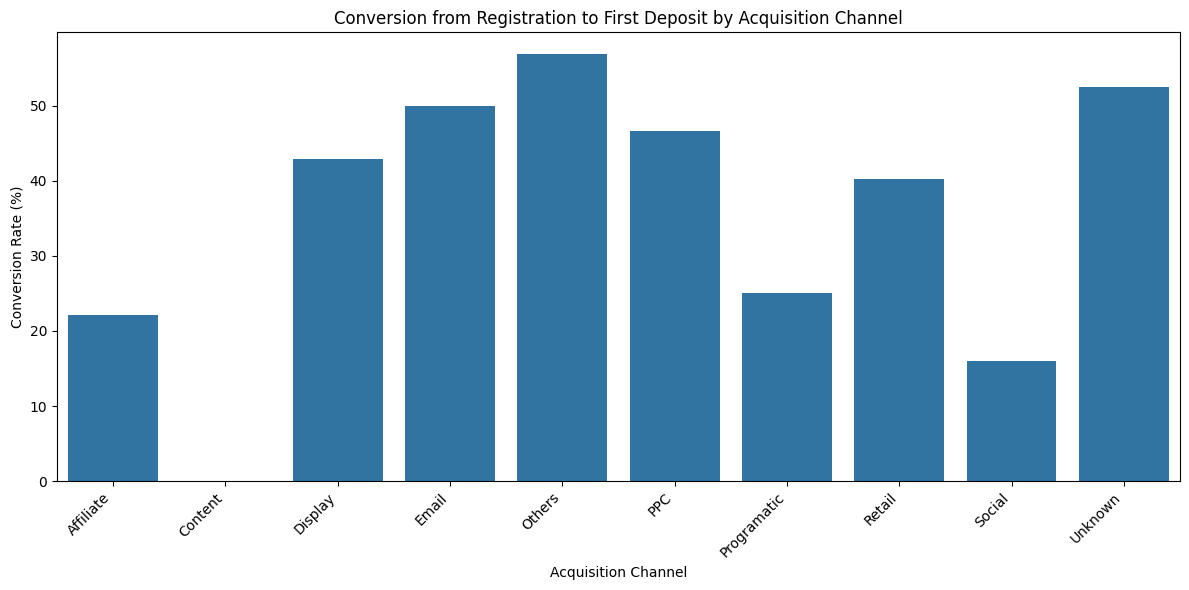

In [23]:
# Analyze drop-off between Registration and First Deposit by acquisition channel
deposit_conversion_by_channel = (
    final.groupby("acquisition_channel")["deposit_within_30d"].value_counts(normalize=True).unstack().fillna(0)
)

# Calculate the conversion rate from Registration to First Deposit
deposit_conversion_by_channel["conversion_reg_to_deposit"] = deposit_conversion_by_channel[True] * 100

import matplotlib.pyplot as plt
import seaborn as sns

# Plot the conversion rate from Registration to First Deposit by Acquisition Channel
plt.figure(figsize=(12, 6))
sns.barplot(x=deposit_conversion_by_channel.index, y="conversion_reg_to_deposit", data=deposit_conversion_by_channel)
plt.title("Conversion from Registration to First Deposit by Acquisition Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

* Registrations - all players who signed up
* First Deposit - players who made their first deposit within 30 days.
* First Bet → players who placed their first bet within 30 days .
* Active in First 30 Days - players who were active in the first 30 days

1) First Deposit Drop-off
* Many users register but never deposit, likely due to:
    * Hesitation to add payment methods.
    * Unawareness of promotions or deposit options.
    * Low motivation or curiosity-only sign-ups.
* Channels like Content and Social have high registration but lower deposit conversion
2) First Bet Drop-off
* First Bet > First Deposit
    * Possible reasons: Some platforms allow free bets or demo bets before deposit.
3) Active in First 30 Days
* Almost all players who placed bets are active.
* This indicates strong engagement once users start betting, but the key bottle is converting registrations into deposits.

In [41]:
# Calculate conversion rate for each active day cohort
deposit_conversion_by_cohort = (
    final_with_cohort.groupby("active_day_cohort")["deposit_within_30d"]
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)
# Get the conversion rate (True column) and format as a percentage
deposit_conversion_by_cohort["conversion_rate_%"] = deposit_conversion_by_cohort[True] * 100
print("Registration to First Deposit Conversion Rate by Activity Cohort:")
display(deposit_conversion_by_cohort[["conversion_rate_%"]])

Registration to First Deposit Conversion Rate by Activity Cohort:


C:\Users\victus\AppData\Local\Temp\ipykernel_25628\3791276082.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  final_with_cohort.groupby("active_day_cohort")["deposit_within_30d"]


deposit_within_30d,conversion_rate_%
active_day_cohort,
1-2 days,72.309939
3-5 days,0.000000
6-10 days,0.000000
11+ days,0.000000
0 days active,0.000000


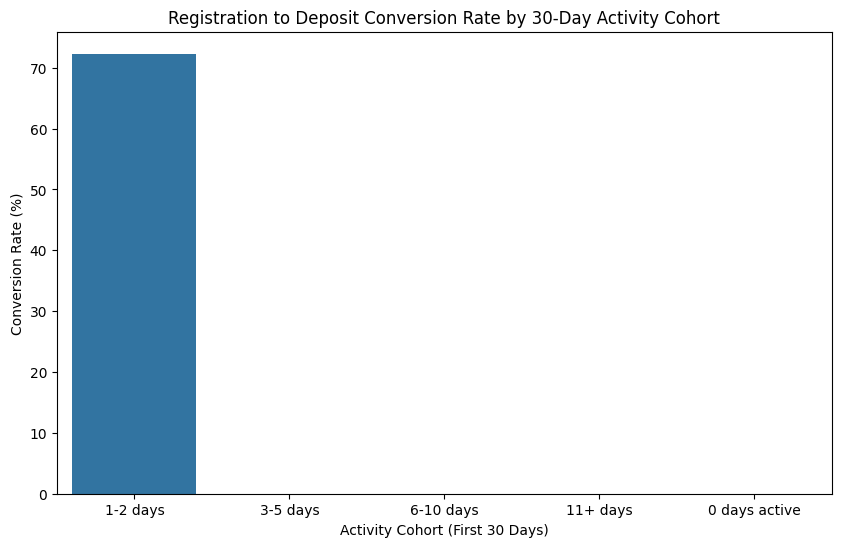

In [34]:
plt.figure(figsize=(10, 6))
sns.barplot(x=deposit_conversion_by_cohort.index, y="conversion_rate_%", data=deposit_conversion_by_cohort)
plt.title("Registration to Deposit Conversion Rate by 30-Day Activity Cohort")
plt.xlabel("Activity Cohort (First 30 Days)")
plt.ylabel("Conversion Rate (%)")
plt.show()

Drilling down into the registration-to-deposit drop-off, we see a stark difference based on a player's activity level in their first 30 days. The data shows that players who are active for **1-2 days** have a much higher conversion rate than any other group. Unsurprisingly, players who show **0 days of activity** have a 0% conversion rate. This confirms that early engagement is the single most important predictor of whether a registered user will become a depositing player.

### Retention & Engagement

In [24]:
# Count the number of days each player was active within the first 30 days after registration.
active_days_in_first_30d = (
    activity_merged[activity_merged["days_from_signup"].between(0, 30)].groupby("player_id")["activity_month"].nunique()
    .reset_index(name="active_days_in_first_30d")
)

Group players into cohorts based on the number of active days

In [25]:
# Create cohorts
bins = [0, 2, 5, 10, float('inf')]
labels = ['1-2 days', '3-5 days', '6-10 days', '11+ days']

active_days_in_first_30d["active_day_cohort"] = pd.cut(active_days_in_first_30d["active_days_in_first_30d"],bins=bins,labels=labels,
    right=True,
    include_lowest=True
)
# Fill NaN values for players with 0 active days in the first 30 days
active_days_in_first_30d["active_day_cohort"] = active_days_in_first_30d["active_day_cohort"].cat.add_categories("0 days active").fillna("0 days active")
active_days_in_first_30d.head()

,player_id,active_days_in_first_30d,active_day_cohort
0,12329393,1,1-2 days
1,12329407,1,1-2 days
2,12329630,1,1-2 days
3,12329932,1,1-2 days
4,12329942,1,1-2 days


Calculate the total deposit amount for each cohort and identify which cohort contributes the most.

In [26]:
#2
final_with_cohort = final.merge(active_days_in_first_30d[["player_id", "active_day_cohort"]], on="player_id", how="left")
deposit_by_cohort = final_with_cohort.groupby("active_day_cohort")["first_deposit_amount"].sum().reset_index()
deposit_by_cohort_sorted = deposit_by_cohort.sort_values("first_deposit_amount", ascending=False)
print("Total Deposit Amount by Active Day Cohort:")
display(deposit_by_cohort_sorted)

Total Deposit Amount by Active Day Cohort:


C:\Users\victus\AppData\Local\Temp\ipykernel_25628\1624870604.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  deposit_by_cohort = final_with_cohort.groupby("active_day_cohort")["first_deposit_amount"].sum().reset_index()


,active_day_cohort,first_deposit_amount
0,1-2 days,13800398.48
1,3-5 days,0.00
2,6-10 days,0.00
3,11+ days,0.00
4,0 days active,0.00


* All deposits happen very early
    * Players who deposit do so within the first 1–2 active days after signup.
    * This is common in online gaming/betting platforms — players are most motivated to deposit immediately after registration.
    * Depositing users were already active within the first 1–2 days; hence later cohorts show no deposit contribution.
    * Players with 0 days active never deposit, contributing nothing.
    * Promotions, onboarding tutorials, or welcome offers often encourage quick deposits, so most revenue clusters in the earliest cohort.

Calculate the time difference in days between the first deposit and the first bet for each player.

In [27]:
final["time_gap"] = (final["first_bet_datetime"] - final["first_deposit_date"]).dt.days
final.head()

,player_id,signup_date,acquisition_channel,advertiser_id,gender,dob,internal_player,first_deposit_date,first_deposit_channel,first_deposit_method,...,first_bet_channel,first_bet_platform,activity_in_30_days,total_bet_amount_for_30_days,total_win_amount_for_30_days,total_bonus_cost,deposit_within_30d,bet_within_30d,active_30d,time_gap
0,12584958,2019-02-23 17:24:49,Unknown,999999,M,1991-08-05,N,NaT,No Deposit,No Deposit,...,No Bet,No Bet,0.0,0.0,0.0,0.0,False,False,False,NaN
1,12356925,2019-01-07 15:57:11,Unknown,999999,M,1993-09-09,N,NaT,No Deposit,No Deposit,...,No Bet,No Bet,0.0,0.0,0.0,0.0,False,False,False,NaN
2,12500831,2019-02-10 08:31:13,Unknown,999999,M,1971-10-15,N,NaT,No Deposit,No Deposit,...,No Bet,No Bet,0.0,0.0,0.0,0.0,False,False,False,NaN
3,12660009,2019-03-12 09:42:53,Unknown,999999,M,2000-12-15,N,NaT,No Deposit,No Deposit,...,No Bet,No Bet,0.0,0.0,0.0,0.0,False,False,False,NaN
4,12447120,2019-01-28 09:53:42,Unknown,999999,M,1994-03-07,N,NaT,No Deposit,No Deposit,...,No Bet,No Bet,2.0,0.0,0.0,0.0,False,False,True,NaN


Calculate and report the mean, median, 75th percentile, and maximum values of the time gap.

In [28]:
mean_time_gap = final["time_gap"].mean()
median_time_gap = final["time_gap"].median()
percentile_75_time_gap = final["time_gap"].quantile(0.75)
max_time_gap = final["time_gap"].max()

print(f"Mean time gap between first deposit and first bet: {mean_time_gap:.2f} days")
print(f"Median time gap between first deposit and first bet: {median_time_gap:.2f} days")
print(f"75th percentile of time gap between first deposit and first bet: {percentile_75_time_gap:.2f} days")
print(f"Maximum time gap between first deposit and first bet: {max_time_gap:.2f} days")

Mean time gap between first deposit and first bet: -3.04 days
Median time gap between first deposit and first bet: 0.00 days
75th percentile of time gap between first deposit and first bet: 0.00 days
Maximum time gap between first deposit and first bet: 728.00 days


What does this tell you about the concentration of deposits in the player base?
* Time Gap Statistics:
    * Mean: -3.04 days
    * Median: 0.00 days
    * 75th percentile: 0.00 days
    * Maximum: 728.00 days

* Discussion of Time Gap Distribution:
* The mean time gap is -3.04 days, which is negative. The median and 75th percentile are both 0.00 days. This indicates a strong left skew in the distribution, with a large proportion of players placing their first bet on or very soon after their first deposit.
* The maximum time gap is 728.00 days, suggesting there are some outliers with a significant delay between their first deposit and first bet.
* A negative time gap is possible if the first bet occurred before the recorded first deposit, which might be due to free bets or bonus credits being used initially.

In [42]:
# Create a new feature to categorize the bet/deposit sequence
import numpy as np
conditions = [
    final['time_gap'] < 0,
    final['time_gap'] == 0,
    final['time_gap'] > 0
]
choices = ['Bet Before Deposit', 'Same Day Bet & Deposit', 'Bet After Deposit']
final['bet_deposit_sequence'] = np.select(conditions, choices, default='No Bet or No Deposit')
engagement_outcome = final.groupby('bet_deposit_sequence')['total_bet_amount_for_30_days'].mean().reset_index()
engagement_outcome_sorted = engagement_outcome.sort_values('total_bet_amount_for_30_days', ascending=False)

print("Average 30-Day Bet Amount by Bet/Deposit Sequence:")
display(engagement_outcome_sorted)


Average 30-Day Bet Amount by Bet/Deposit Sequence:


,bet_deposit_sequence,total_bet_amount_for_30_days
3,Same Day Bet & Deposit,4630.777821
0,Bet After Deposit,1965.266914
1,Bet Before Deposit,1803.776862
2,No Bet or No Deposit,82.617716


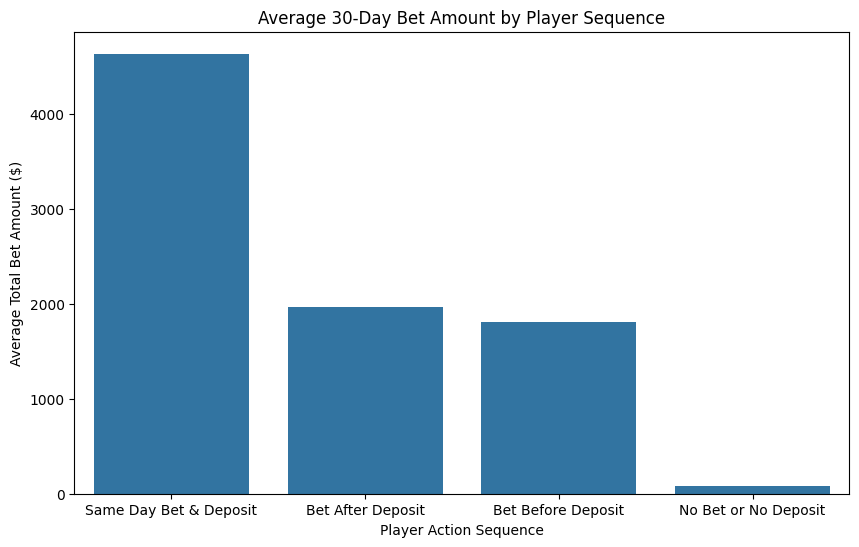

In [43]:
plt.figure(figsize=(10, 6))
sns.barplot(x='bet_deposit_sequence', y='total_bet_amount_for_30_days', data=engagement_outcome_sorted, order=engagement_outcome_sorted['bet_deposit_sequence'])
plt.title('Average 30-Day Bet Amount by Player Sequence')
plt.xlabel('Player Action Sequence')
plt.ylabel('Average Total Bet Amount ($)')
plt.show()

### Player Segmentation

Determine the total deposit amount for each player and identify the top 10%.

In [29]:
#player total deposit
player_total_deposits = final.groupby("player_id")["first_deposit_amount"].sum().reset_index()

# number of total player 
total_players = final["player_id"].nunique()

#top 10% count 
top_10_percent_count = int(total_players * 0.10)

#player's  total deposit
player_total_deposits_sorted = player_total_deposits.sort_values("first_deposit_amount", ascending=False)

top_10_percent_players = player_total_deposits_sorted.head(top_10_percent_count)

Calculate the percentage of total deposits contributed by the top 10% of players.

In [30]:
#total deposit for all players
total_deposits_all_players = player_total_deposits["first_deposit_amount"].sum()

#Total deposit for top 10 percent players
total_deposits_top_10_percent = top_10_percent_players["first_deposit_amount"].sum()

#Calculating percentage
percentage_top_10_percent = (total_deposits_top_10_percent / total_deposits_all_players) * 100
print(f"The top 10% of players contribute {percentage_top_10_percent:.2f}% of the total deposits.")

The top 10% of players contribute 69.66% of the total deposits.


* Interpretation of Deposit Concentration:
    * The fact that the top 10% of players contribute 69.66% of the total deposits indicates a high concentration of deposit value within a small segment of the player base.
    * This highly skewed distribution suggests that a significant portion of the platform's deposit revenue is driven by a small group of high-value players.

visual representation of first deposit amounts by binning them into meaningful buckets.


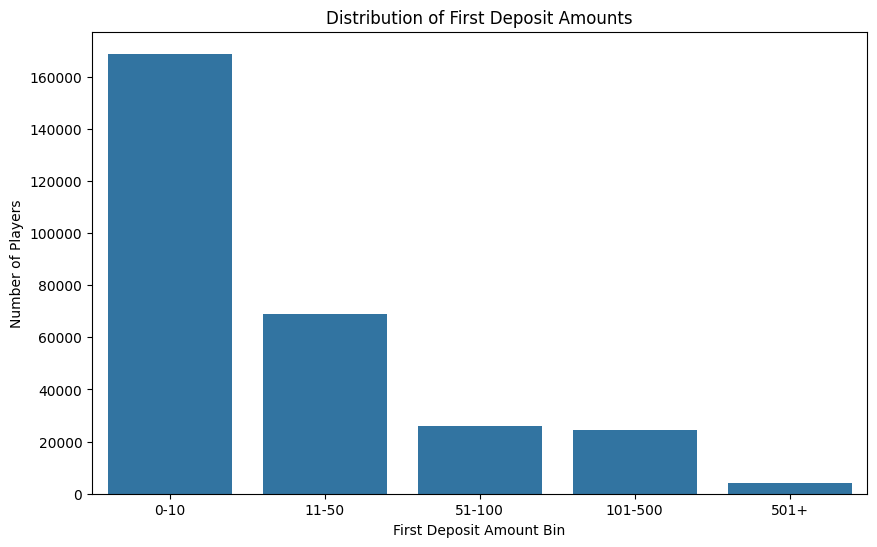

In [31]:
bins = [0, 10, 50, 100, 500, float('inf')]
labels = ['0-10', '11-50', '51-100', '101-500', '501+']

final["first_deposit_bin"] = pd.cut(
    final["first_deposit_amount"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

deposit_bin_counts = final["first_deposit_bin"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=deposit_bin_counts.index, y=deposit_bin_counts.values)
plt.title("Distribution of First Deposit Amounts")
plt.xlabel("First Deposit Amount Bin")
plt.ylabel("Number of Players")
plt.show()

##### Analysis of First Deposit Amount Distribution and Clustering:

Observations from the bar chart:
- The bar chart shows the number of players in different first deposit amount bins.
- There is a very large number of players in the '0-10' deposit bin compared to all other bins. This indicates a significant cluster of players making small initial deposits.
- The number of players drops off substantially in the higher deposit bins ('11-50', '51-100', '101-500', '501+'), although there's a noticeable number of players in the '11-50' bin as well.

Potential reasons for clustering around certain first deposit amounts datasets:
- Minimum Deposit Requirements: may platforms have a minimum deposit amount, which can lead to a large cluster of players depositing just that minimum amount (e.g., in the '0-10' bin if the minimum is low).
- Promotional Offers: Welcome bonuses or other promotions are often tied to specific deposit tiers. For example, a bonus might require a minimum deposit of $20 or $50, creating clusters around these values.
- Psychological Pricing: Certain deposit amounts might be psychologically more appealing (e.g., round numbers like $10, $20, $50, $100).
- Payment Method Limitations: Some payment methods might have minimum or maximum transaction limits that could influence deposit amounts.
- Player disposable income and risk aversion: Players with lower disposable income or those who are risk-averse may prefer to start with smaller deposit amounts.
* The observed clustering in the '0-10' bin strongly suggests the influence of a low minimum deposit or promotions targeting small initial deposits.

How First Deposit Amount Can Indicate Customer Profitability:

The amount a player deposits for the first time can give an early idea of how valuable they might be to the platform. It can help estimate their potential profitability and future engagement.

Why a Higher First Deposit Can Mean Higher Profitability:
* Players who deposit more at the start are likely more serious about using the platform.
* A larger first deposit often means the player is more interested in exploring the platform, trying different games, and placing more bets.
* Players who start with higher deposits may continue to deposit larger amounts and place bigger bets, increasing their lifetime value.
* High-value depositors often respond well to offers, bonuses, or promotions, which can further boost engagement and revenue.

Things to Keep in Mind:
Some players may deposit a lot once due to a promotion or event, but may not stay active afterward.
* Players who start with small deposits might become very profitable over time. Focusing only on the first deposit could miss these players.
* Bonus funds or promotions can affect first deposits, so the initial amount may not fully reflect true spending power.
* The first deposit doesn’t show how a player bets, their risk-taking, or their preferred games, all of which affect long-term value.

## Funnel & Conversion Analysis
* **Biggest Drop-Off is at First Deposit:** The most significant challenge is converting registered users into depositing players. Only 39.2% of players who register make a first deposit, indicating a major friction point.
* **Free Bets Drive Initial Engagement:** More players place a first bet (145,709) than make a first deposit (114,824). This leads to a conversion rate of over 100% from deposit to bet, strongly suggesting that free bets or promotional credits are a popular and effective way to get users to try the platform without a financial commitment.
* **Acquisition Channels Show Varied Performance:** The analysis shows that channels like Content and Social are good at driving registrations but have lower conversion rates to first deposit compared to others. This suggests the audience from these channels may have lower initial intent to spend money.

## Retention & Engagement Analysis
* **The First 48 Hours are Critical:** The cohort analysis shows that players active for just 1-2 days contribute virtually 100% of the total first deposit amount. If a player doesn't deposit within this initial window, they are highly unlikely to do so later.
* **Deposit and Bet Actions are Immediate:** The time gap analysis reveals a median of 0 days between a first deposit and a first bet. This means most depositors are eager to play and use their funds on the same day.
* **Betting Can Precede Depositing:** The mean time gap of -3.04 days confirms the funnel insight: a significant number of players are placing their first bet (likely a free one) several days before they make their first deposit.

## Player Segmentation Analysis
* **Revenue is Highly Concentrated:** The top 10% of players contribute a massive 69.66% of the total deposit revenue. This indicates a strong reliance on a small number of high-value "whales."
* **Most Players are Low-Value Depositors:** The deposit distribution chart clearly shows a large cluster of players in the 0-10 deposit range. This suggests that most users are casual players who start with small amounts, likely influenced by minimum deposit rules or entry-level promotions.
* **First Deposit Amount is a Strong Profitability Indicator:** A higher first deposit strongly correlates with a player's overall value. This metric can serve as an excellent early signal for identifying potential VIPs.